# QA: hand-check `data/processed` pipeline output

Sanity-checks the output of whatever `uv run python -m neuroalign.data.preprocessing.cli` run produced `data/processed`. No BAG modeling here — just: does the data look right, and is it even loadable by the current codebase.

Point `STORE_ROOT` at whichever run you want to inspect (default: `data/processed`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from neuroalign.data.preprocessing import FeatureStore
from neuroalign.modeling.bag_store import BAGStore

sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
STORE_ROOT = project_root / "data" / "processed_full"
store = FeatureStore(STORE_ROOT)

## 1. Manifest summary

In [2]:
summary = store.summary()
print(f"root: {summary['root_dir']}")
print(f"atlas: {summary['atlas_name']}")
print(f"sessions: {summary['n_sessions']}  subjects: {summary['n_subjects']}")
print(f"long formats: {summary['long_formats']}")
print(f"wide features: {summary['n_wide_features']}")
print(f"  anatomical: {len(summary['anatomical_features'])}")
print(f"  diffusion:  {len(summary['diffusion_features'])}")
print(f"has_tiv: {summary['has_tiv']}")
print(f"created: {summary['created_at']}  updated: {summary['updated_at']}")

root: /home/galkepler/Projects/neuroalign/data/processed_full
atlas: Schaefer2018N400n7Tian2020S2
sessions: 3693  subjects: 2829
long formats: ['anatomical', 'diffusion_AMICONODDI', 'diffusion_DIPYDKI', 'diffusion_DIPYMAPMRI', 'diffusion_DSIStudio', 'diffusion_MRtrix3actHSVS']
wide features: 1344
  anatomical: 24
  diffusion:  1320
has_tiv: True
created: 2026-07-01T15:07:41.890000  updated: 2026-07-01T15:21:04.066745


## 2. Metadata

Check schema, id columns, duplicates, age distribution.

In [3]:
meta = store.load_metadata()
print(f"{len(meta)} rows, columns: {list(meta.columns)}")

id_candidates = [c for c in ("uid", "subject_code") if c in meta.columns]
print(f"id column(s) present: {id_candidates}")
if "uid" not in meta.columns:
    print(
        "WARNING: no 'uid' column. FeatureStore.load_feature/load_features merge "
        "metadata on ['uid', 'session_id'] (see META_COLS in feature_store.py) — "
        "that merge will KeyError against this metadata file."
    )

meta.head()

3749 rows, columns: ['session_id', 'uid', 'subject_code', 'subject_code_bids', 'lab', 'scan_date', 'scan_tag', 'scan_number', 'protocol', 'study', 'group_label', 'mapping_complete', 'AGE', 'sex', 'weight_kg', 'height_m', 'dominant_hand']
id column(s) present: ['uid', 'subject_code']


,session_id,uid,subject_code,subject_code_bids,lab,scan_date,scan_tag,scan_number,protocol,study,group_label,mapping_complete,AGE,sex,weight_kg,height_m,dominant_hand
0,202012061756,S004192,0336,None,YA,2020-12-06,Pre,2,Sport,Climbing,Learning,True,25.420000,Female,65.00,1.700,None
1,202601111959,S629697,GYM_L_23,None,YA,2026-01-11,Post,2,SNBB_YA_Sport,YA_Gymnastic,Learner,True,37.691992,Female,79.35,1.645,None
2,202601181721,S667793,GYM_C_04,None,YA,2026-01-18,Pre,2,SNBB_YA_Sport,YA_Gymnastic,Control,True,27.641342,Female,49.00,1.582,None
3,202601051400,S307570,BB01630,None,SNBB,2026-01-05,None,1,SNBB_DB,DB_SNBB,N/A,True,25.262149,Female,80.00,1.688,None
4,202410131245,S076379,BB01028,None,TS,2024-10-13,None,2,Brain Bank,TS,None,True,22.260000,Female,67.00,1.610,None


duplicate ['uid', 'session_id'] rows: 0
count    3747.000000
mean       31.280881
std         9.856305
min         9.234771
25%        24.566735
50%        28.227242
75%        35.475797
max        86.240000
Name: AGE, dtype: float64


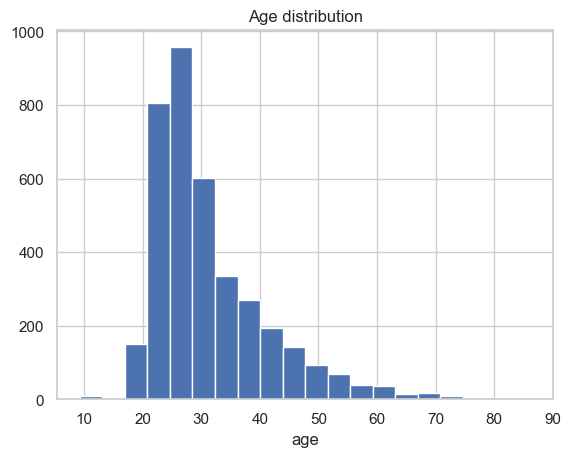

sex
Male      2260
Female    1487
None         2
Name: count, dtype: int64


In [4]:
if "session_id" in meta.columns and id_candidates:
    dup_key = [id_candidates[0], "session_id"]
    n_dupes = meta.duplicated(subset=dup_key).sum()
    print(f"duplicate {dup_key} rows: {n_dupes}")

if "AGE" in meta.columns:
    print(meta["AGE"].describe())
    meta["AGE"].hist(bins=20)
    plt.xlabel("age")
    plt.title("Age distribution")
    plt.show()
else:
    print("No 'AGE' column in metadata — BAG estimation needs an age column.")

for col in ("sex", "Sex", "Group"):
    if col in meta.columns:
        print(meta[col].value_counts(dropna=False))

## 3. Does `FeatureStore` actually see this data?

`get_existing_sessions()` silently skips any long-format parquet whose id column
doesn't match `META_COLS = ["uid", "session_id"]` (see the try/except in
`feature_store.py`). If this run predates the `uid` convention, the pipeline
will think there is *no* existing data here and BAG estimation / incremental
loading will silently misbehave.

In [5]:
existing = store.get_existing_sessions()
print(f"get_existing_sessions(): {len(existing)} sessions recognized")
if len(existing) == 0 and summary["n_sessions"] > 0:
    print(
        "MISMATCH: manifest reports "
        f"{summary['n_sessions']} sessions but get_existing_sessions() sees 0 — "
        "schema mismatch between stored parquet id columns and the code's expected "
        "'uid' column. Confirm with the raw-parquet check below."
    )

get_existing_sessions(): 3749 sessions recognized


In [6]:
features = store.list_features()
print(f"{len(features)} wide features available")
if features:
    try:
        test = store.load_feature(features[0])
        print(f"load_feature('{features[0]}') OK -> {test.shape}")
    except Exception as e:
        print(f"load_feature('{features[0]}') FAILED: {type(e).__name__}: {e}")

1344 wide features available
load_feature('AMICONODDI_noddi_direction_coverage') OK -> (3693, 449)


## 4. Raw parquet check (bypassing `FeatureStore` helpers)

If step 3 failed or returned 0 sessions, inspect the files directly to judge
data quality independent of the loader bug.

In [7]:
def raw_feature_report(path: Path) -> None:
    df = pd.read_parquet(path)
    id_cols = [c for c in ("uid", "subject_code") if c in df.columns] + ["session_id"]
    region_cols = [c for c in df.columns if c not in ("uid", "subject_code", "session_id")]
    nan_rate = df[region_cols].isna().mean()
    print(f"{path.relative_to(STORE_ROOT)}")
    print(f"  shape: {df.shape}  id cols: {id_cols}  n_regions: {len(region_cols)}")
    print(f"  duplicate id rows: {df.duplicated(subset=id_cols).sum()}")
    print(f"  per-region NaN rate: mean={nan_rate.mean():.3f} max={nan_rate.max():.3f}")
    print(df[region_cols].stack().describe())


anat_files = sorted((STORE_ROOT / "wide" / "anatomical").glob("*.parquet")) if (STORE_ROOT / "wide" / "anatomical").exists() else []
for p in anat_files[:3]:
    raw_feature_report(p)
    print()

wide/anatomical/anat_brain_seg_no_vent_mm3.parquet
  shape: (1682, 402)  id cols: ['uid', 'session_id']  n_regions: 400
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    6.728000e+05
mean     1.117967e+06
std      1.037081e+05
min      7.472140e+05
25%      1.044722e+06
50%      1.117122e+06
75%      1.188734e+06
max      1.388697e+06
dtype: float64

wide/anatomical/anat_brain_seg_vol_mm3.parquet
  shape: (1682, 402)  id cols: ['uid', 'session_id']  n_regions: 400
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    6.728000e+05
mean     1.445803e+06
std      1.298198e+05
min      1.007681e+06
25%      1.348609e+06
50%      1.452578e+06
75%      1.534377e+06
max      1.841846e+06
dtype: float64

wide/anatomical/anat_cortex_vol_mm3.parquet
  shape: (1682, 402)  id cols: ['uid', 'session_id']  n_regions: 400
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    672800.000000
mean     475501.242139
std       44954.9363

In [8]:
diff_files = sorted((STORE_ROOT / "wide" / "diffusion").glob("*.parquet")) if (STORE_ROOT / "wide" / "diffusion").exists() else []
for p in diff_files[:3]:
    raw_feature_report(p)
    print()

wide/diffusion/AMICONODDI_noddi_direction_coverage.parquet
  shape: (3693, 434)  id cols: ['uid', 'session_id']  n_regions: 432
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    1595376.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
dtype: float64

wide/diffusion/AMICONODDI_noddi_direction_cv.parquet
  shape: (3693, 434)  id cols: ['uid', 'session_id']  n_regions: 432
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    1.595376e+06
mean    -1.829215e+00
std      2.762788e+01
min     -1.165069e+04
25%     -2.125389e+00
50%     -1.716201e+00
75%     -1.408068e+00
max      2.048319e+04
dtype: float64

wide/diffusion/AMICONODDI_noddi_direction_excess_kurtosis.parquet
  shape: (3693, 434)  id cols: ['uid', 'session_id']  n_regions: 432
  duplicate id rows: 0
  per-region NaN rate: mean=0.000 max=0.000
count    1.595370e+06
mean    -4.011670e-01
std      1

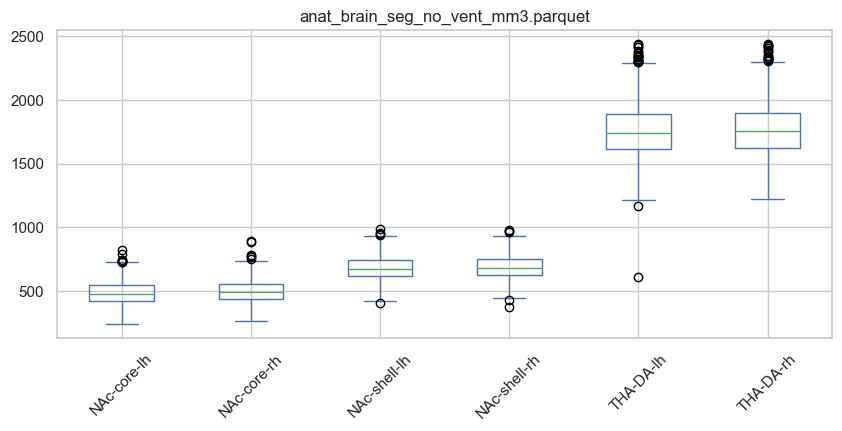

In [14]:
# Eyeball a handful of regions for one feature — do the values look like
# plausible anatomy (e.g. GM volume mm^3 in the hundreds-to-thousands range,
# not zeros / negatives / wildly discontinuous across subjects)?
if anat_files:
    df = pd.read_parquet([i for i in anat_files if i.name == "anat_volume_mm3.parquet"][0])
    region_cols = [c for c in df.columns if c not in ("uid", "subject_code", "session_id")]
    sample_regions = region_cols[:6]
    df[sample_regions].plot(kind="box", figsize=(10, 4), rot=45, title=anat_files[0].name)
    plt.show()

## 5. TIV

In [15]:
if store.has_tiv():
    tiv = store.load_tiv()
    print(tiv.describe())
else:
    print("No TIV computed for this run.")

            tiv_mm3
count  1.682000e+03
mean   1.567726e+06
std    1.485881e+05
min    1.119635e+06
25%    1.462141e+06
50%    1.573542e+06
75%    1.669170e+06
max    2.022730e+06


## 6. BAG results

`BAGStore` only sees results under `<root>/bag/{univariate,multivariate}/`.
`--run-bag-estimation` is off by default in the CLI — if this run didn't pass
it, there is nothing here to judge yet.

In [16]:
bag_store = BAGStore(STORE_ROOT)
names = bag_store.list()
print(f"BAG results found: {names}")

if not names:
    print(
        "No BAG results in this store. Re-run the CLI with "
        "--run-bag-estimation (plus --bag-all-univariate / --bag-all-multivariate) "
        "to generate them, then re-run this cell."
    )

BAG results found: ['univariate/AMICONODDI_noddi_direction_coverage', 'univariate/AMICONODDI_noddi_direction_cv', 'univariate/AMICONODDI_noddi_direction_excess_kurtosis', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_mean', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_std', 'univariate/AMICONODDI_noddi_direction_mad_median', 'univariate/AMICONODDI_noddi_direction_mean', 'univariate/AMICONODDI_noddi_direction_median', 'univariate/AMICONODDI_noddi_direction_percentile_25', 'univariate/AMICONODDI_noddi_direction_percentile_5', 'univariate/AMICONODDI_noddi_direction_percentile_75', 'univariate/AMICONODDI_noddi_direction_percentile_95', 'univariate/AMICONODDI_noddi_direction_robust_cv', 'univariate/AMICONODDI_noddi_direction_robust_mean', 'univariate/AMICONODDI_noddi_direction_robust_std', 'univariate/AMICONODDI_noddi_direction_skewness', 'univariate/AMICONODDI_noddi_direction_std', 'univariate/AMICONODDI_noddi_direction_sum', 'univariate/AMICONODDI_noddi_direction_volume_mm3',

In [ ]:
for name in names:
    result = bag_store.load_result(name)
    rm = result.region_metrics
    print(f"--- {name} ---")
    print(rm[["r2", "mae"]].describe() if {"r2", "mae"}.issubset(rm.columns) else rm.describe())
    n_bad = (rm["r2"] < 0).sum() if "r2" in rm.columns else None
    if n_bad is not None:
        print(f"regions with r2 < 0: {n_bad} / {len(rm)}")
    print()

--- univariate/AMICONODDI_noddi_direction_coverage ---
                 r2           mae
count  4.320000e+02  4.320000e+02
mean  -1.260366e+00  1.092407e+01
std    4.446041e-16  3.556833e-15
min   -1.260366e+00  1.092407e+01
25%   -1.260366e+00  1.092407e+01
50%   -1.260366e+00  1.092407e+01
75%   -1.260366e+00  1.092407e+01
max   -1.260366e+00  1.092407e+01
regions with r2 < 0: 432 / 432

--- univariate/AMICONODDI_noddi_direction_cv ---
                 r2          mae
count  4.320000e+02   432.000000
mean  -2.372914e+06    30.544436
std    4.755454e+07   320.034738
min   -9.880891e+08    10.022931
25%   -1.411516e+00    10.835349
50%   -1.321010e+00    10.962940
75%   -1.265913e+00    11.119777
max   -1.016507e+00  6546.246933
regions with r2 < 0: 432 / 432

--- univariate/AMICONODDI_noddi_direction_excess_kurtosis ---
                 r2          mae
count  4.320000e+02   432.000000
mean  -1.674532e+06    34.625326
std    2.970190e+07   268.301215
min   -6.134275e+08     9.596192
25

## 7. Verdict

Fill in after running the cells above:
- Metadata id column matches `uid`? 
- `get_existing_sessions()` count matches manifest `n_sessions`? 
- Any feature NaN rate > 0? 
- Region value ranges plausible? 
- Any BAG results present, and do region r2 look better than chance?